In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load AQI data
aqi_df = pd.read_csv("/content/merged_with_numerical_aqi.csv")

# Parse timestamp
aqi_df['timestamp'] = pd.to_datetime(aqi_df['timestamp'])

In [50]:
#Show the first few rows
print("First 5 rows of the dataset:")
aqi_df.head()

First 5 rows of the dataset:


,aqi_category,co,coco,day,day_of_week,day_of_year,day_of_year_cos,day_of_year_sin,dew_point,hour,...,temperature,timestamp,tsun,week_cos,week_of_year,week_sin,wind_direction,wind_speed,wpgt,numerical_aqi
0,5.0,2296.45,5.0,4,1,63,0.467359,0.884068,8.1,0,...,9.0,2025-03-04 00:00:00,NaN,0.354605,10,0.935016,0.0,0.0,NaN,178.0
1,5.0,2136.23,5.0,4,1,63,0.467359,0.884068,7.0,1,...,7.0,2025-03-04 01:00:00,NaN,0.354605,10,0.935016,219.0,6.5,NaN,175.0
2,5.0,2189.64,5.0,4,1,63,0.467359,0.884068,7.0,2,...,7.0,2025-03-04 02:00:00,NaN,0.354605,10,0.935016,225.0,6.5,NaN,176.0
3,5.0,2616.88,5.0,4,1,63,0.467359,0.884068,9.0,3,...,9.0,2025-03-04 03:00:00,NaN,0.354605,10,0.935016,180.0,3.6,NaN,180.0
4,5.0,3150.94,5.0,4,1,63,0.467359,0.884068,6.9,4,...,11.0,2025-03-04 04:00:00,NaN,0.354605,10,0.935016,203.0,5.0,NaN,186.0


In [51]:
# 3. Dataset structure
print("\n Dataset info:")
aqi_df.info()


 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   aqi_category       4001 non-null   float64       
 1   co                 4001 non-null   float64       
 2   coco               3837 non-null   float64       
 3   day                4001 non-null   int64         
 4   day_of_week        4001 non-null   int64         
 5   day_of_year        4001 non-null   int64         
 6   day_of_year_cos    4001 non-null   float64       
 7   day_of_year_sin    4001 non-null   float64       
 8   dew_point          3893 non-null   float64       
 9   hour               4001 non-null   int64         
 10  is_weekend         4001 non-null   int64         
 11  month              4001 non-null   int64         
 12  nh3                4001 non-null   float64       
 13  no                 4001 non-null   float64     

In [52]:
# 7. Check date range
print("\n Data time range:")
print(f"From {aqi_df['timestamp'].min()} to {aqi_df['timestamp'].max()}")


 Data time range:
From 2025-03-04 00:00:00 to 2025-08-27 16:00:00


In [53]:
# 8. Check unique AQI values (should be categorical 1–5)
print("\n Unique AQI values:")
print(aqi_df['aqi_category'].unique())


 Unique AQI values:
[5.         4.         3.         2.         4.66662979]


In [54]:
# Round off AQI values to nearest integer
aqi_df['aqi_category'] = aqi_df['aqi_category'].round().astype(int)

# Confirm unique values
print("Unique AQI values after rounding:")
print(aqi_df['aqi_category'].unique())

Unique AQI values after rounding:
[5 4 3 2]


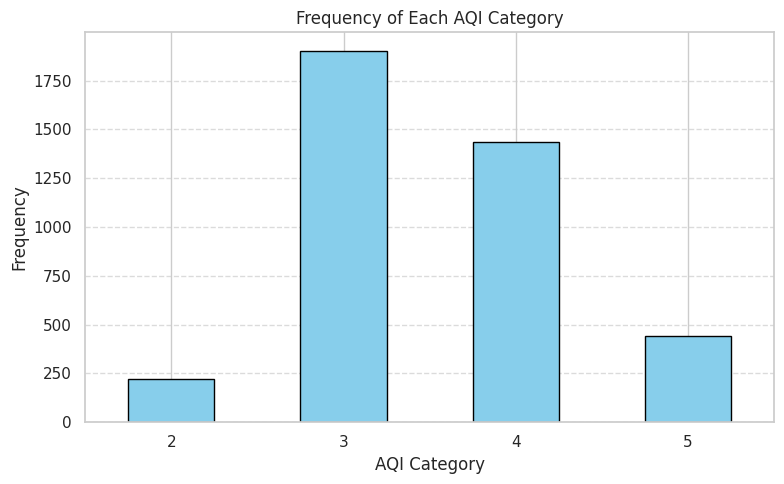

In [55]:
# Count frequency of each AQI category
aqi_counts = aqi_df['aqi_category'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(8, 5))
aqi_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Frequency of Each AQI Category')
plt.xlabel('AQI Category')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Reveals the data is imbalanced,helps inform the choice of models and techniques, such as oversampling or CatBoost, to ensure the system doesn't underperform on rarer categories

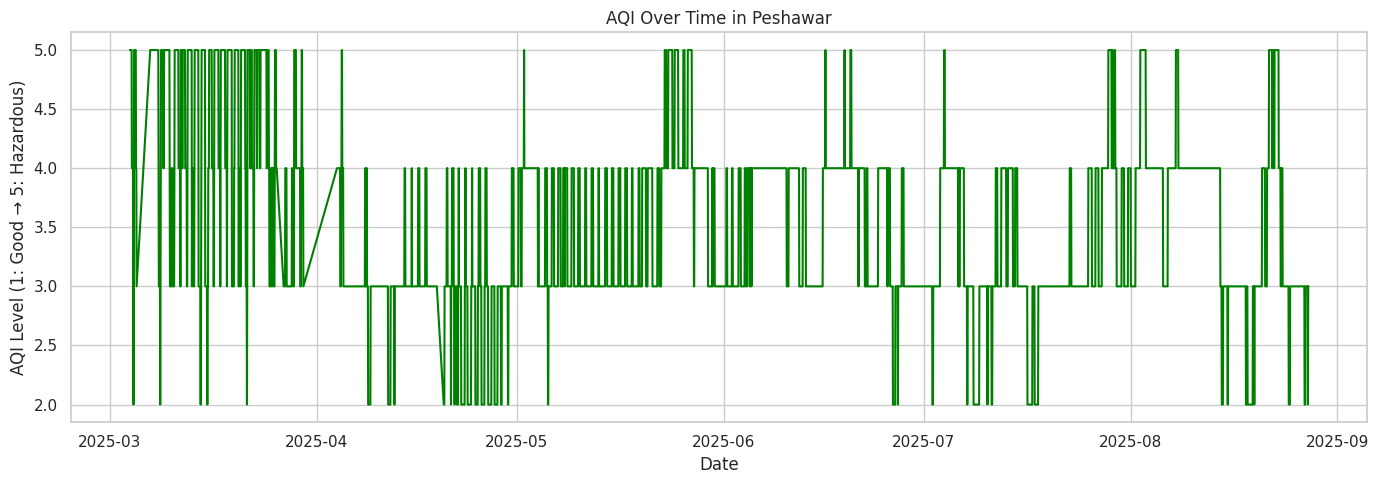

In [56]:
#AQI Trends Over Time
plt.figure(figsize=(14,5))
plt.plot(aqi_df['timestamp'], aqi_df['aqi_category'], color='green')
plt.title("AQI Over Time in Peshawar")
plt.xlabel("Date")
plt.ylabel("AQI Level (1: Good → 5: Hazardous)")
plt.grid(True)
plt.tight_layout()
plt.show()
#historical trend of AQI levels, helping to identify seasonal patterns and abrupt changes.

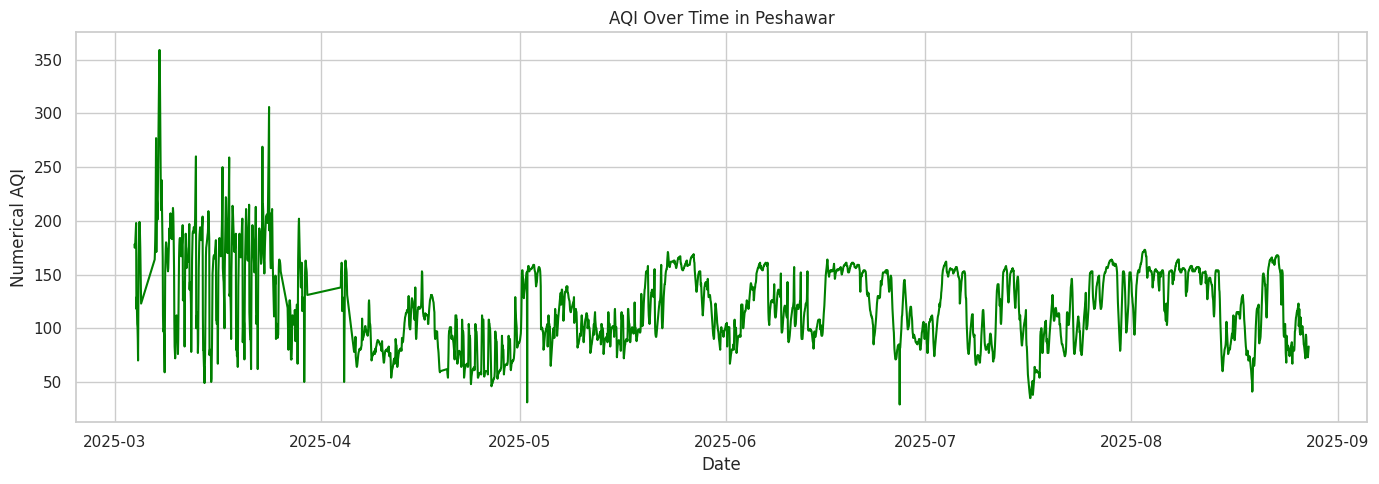

In [57]:
#AQI Trends Over Time
plt.figure(figsize=(14,5))
plt.plot(aqi_df['timestamp'], aqi_df['numerical_aqi'], color='green')
plt.title("AQI Over Time in Peshawar")
plt.xlabel("Date")
plt.ylabel("Numerical AQI")
plt.grid(True)
plt.tight_layout()
plt.show()
#time-series visualization of continuous AQI values, showing fluctuations and trends.identifies patterns, volatility, and outliers, which informs feature engineering and helps in selecting the most suitable time-series models (like TCN) for forecasting.

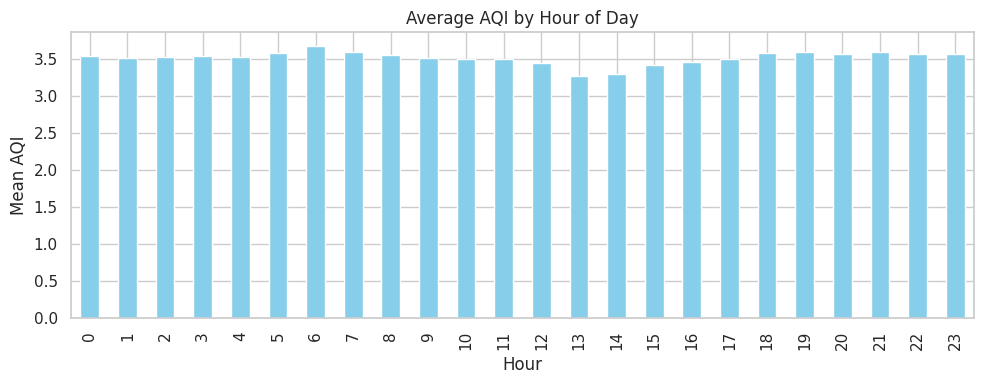

In [58]:
#Average Categorical AQI by Hour of Day
aqi_df.groupby('hour')['aqi_category'].mean().plot(kind='bar', figsize=(10,4), color='skyblue')
plt.title("Average AQI by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Mean AQI")
plt.grid(True)
plt.tight_layout()
plt.show()
#dentifies diurnal patterns in AQI, such as lower levels in the afternoon, models can learn to anticipate hourly fluctuations, improving forecasting accuracy

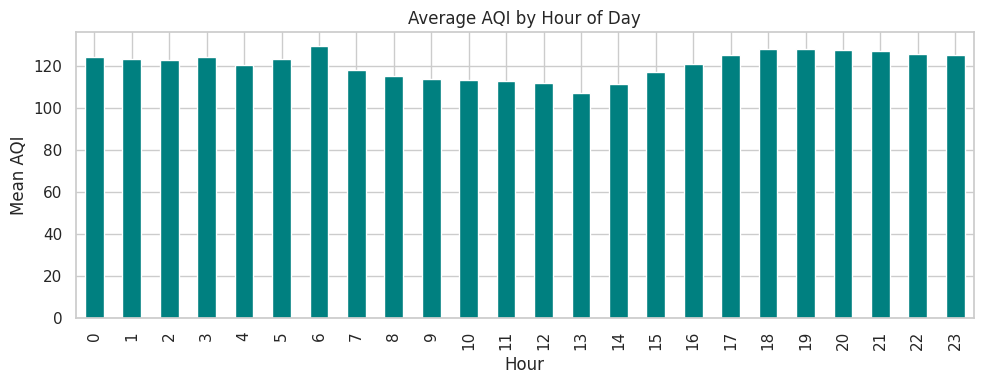

In [59]:
#Average AQI by Hour of Day
aqi_df.groupby('hour')['numerical_aqi'].mean().plot(kind='bar', figsize=(10,4), color='teal')
plt.title("Average AQI by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Mean AQI")
plt.grid(True)
plt.tight_layout()
plt.show()
#hourly cyclical patterns of the continuous AQI values,  identify times of day with higher or lower pollution

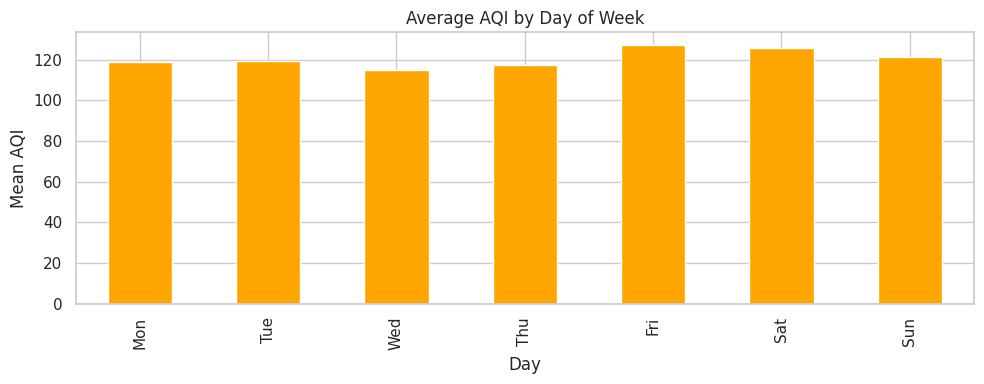

In [60]:
#Average AQI by Day of Week
weekday_map = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
aqi_df['day_label'] = aqi_df['day_of_week'].map(lambda x: weekday_map[x])

aqi_df.groupby('day_label')['numerical_aqi'].mean().reindex(weekday_map).plot(
    kind='bar', figsize=(10,4), color='orange')
plt.title("Average AQI by Day of Week")
plt.xlabel("Day")
plt.ylabel("Mean AQI")
plt.grid(True)
plt.tight_layout()
plt.show()
#weekly patterns in AQI levels, revealing that pollution may be higher on certain days, like weekends. This insight helps in creating day-of-week features

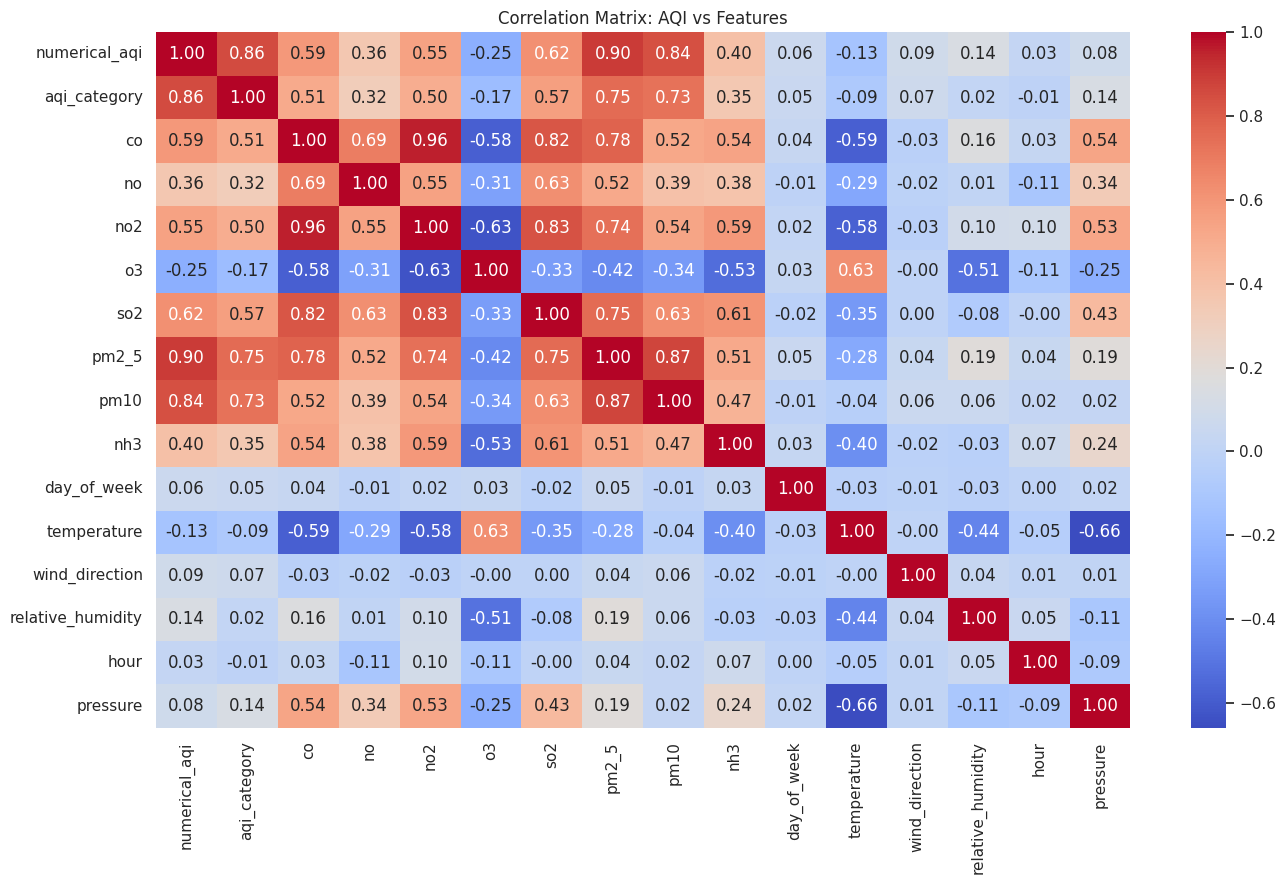

In [61]:
#Pollutant Correlation with AQI
plt.figure(figsize=(14,9))
corr = aqi_df[['numerical_aqi','aqi_category', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3','day_of_week','temperature','wind_direction','relative_humidity','hour','pressure']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: AQI vs Features")
plt.tight_layout()
plt.show()
#trength and direction of relationships between all variables.identify which features—like PM2.5 and PM10—have the strongest correlation with AQI, providing a basis for feature selection and engineering and helping to avoid using highly correlated features that would negatively impact model performance.

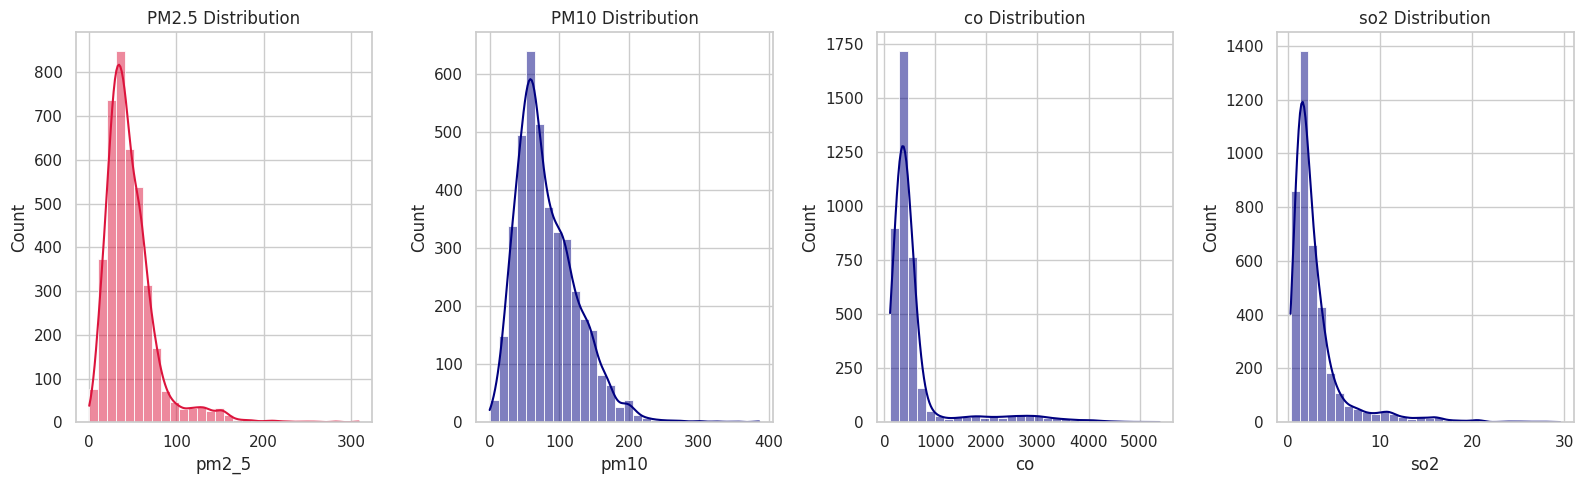

In [62]:
#Distribution of PM2.5 & PM10
plt.figure(figsize=(20,5))

plt.subplot(1, 5, 1)
sns.histplot(aqi_df['pm2_5'], bins=30, kde=True, color='crimson')
plt.title("PM2.5 Distribution")

plt.subplot(1, 5, 2)
sns.histplot(aqi_df['pm10'], bins=30, kde=True, color='navy')
plt.title("PM10 Distribution")

plt.subplot(1, 5, 3)
sns.histplot(aqi_df['co'], bins=30, kde=True, color='navy')
plt.title("co Distribution")


plt.subplot(1, 5, 4)
sns.histplot(aqi_df['so2'], bins=30, kde=True, color='navy')
plt.title("so2 Distribution")

plt.tight_layout()
plt.show()
#series of plots shows the distribution of key pollutants like PM2.5 and CO. Understanding their distributions helps in data preprocessing, such as identifying skewness and potential outliers,
#Both PM2.5 and PM10 distributions are right-skewed and not normally distributed. They show tails extending to higher values rather than isolated extreme spikes.

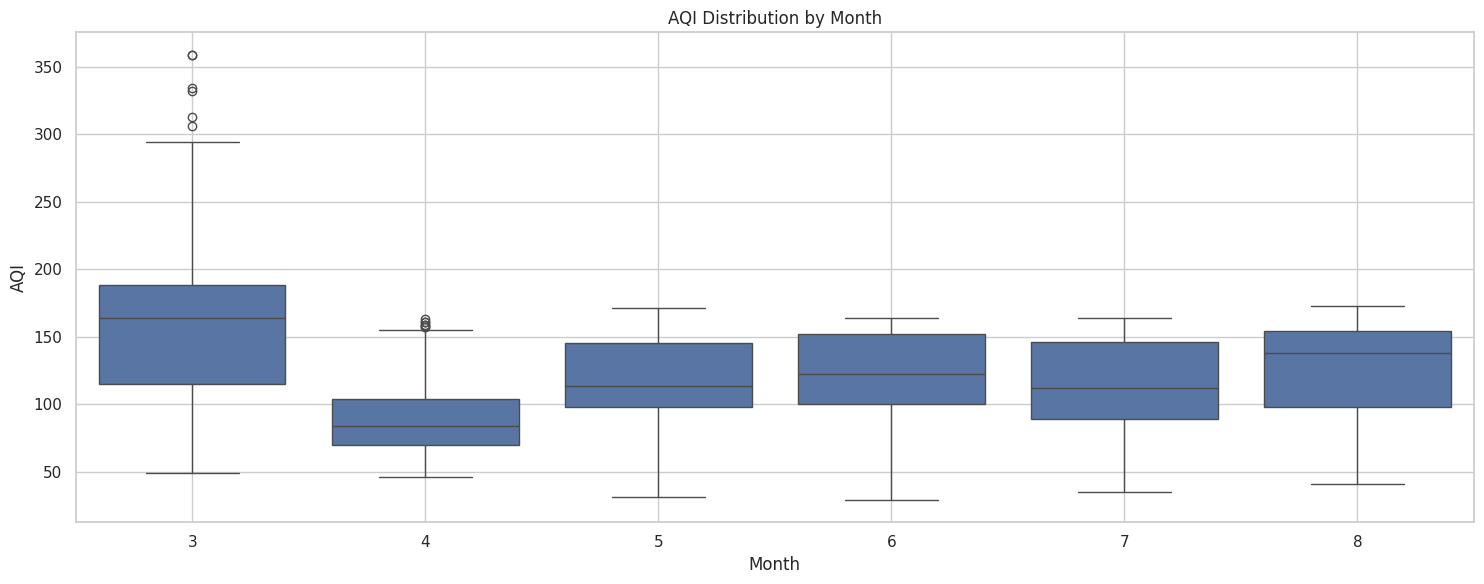

In [63]:
#Daily AQI Boxplot
plt.figure(figsize=(15,6))
sns.boxplot(x='month', y='numerical_aqi', data=aqi_df)
plt.title("AQI Distribution by Month")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.grid(True)
plt.tight_layout()
plt.show()
# seasonal variations in AQI levels, showing higher pollution during colder months and lower levels during warmer ones. This crucial insight helps the system by allowing the models to learn these monthly patterns

#**Week2**

In [64]:
# Show how many rows were merged
print(f"Merged rows: {len(aqi_df)}")

Merged rows: 4001


In [65]:
# Show missing value counts
print("\n Missing values BEFORE cleaning:")
print(aqi_df.isnull().sum())


 Missing values BEFORE cleaning:
aqi_category            0
co                      0
coco                  164
day                     0
day_of_week             0
day_of_year             0
day_of_year_cos         0
day_of_year_sin         0
dew_point             108
hour                    0
is_weekend              0
month                   0
nh3                     0
no                      0
no2                     0
o3                      0
pm10                    0
pm2_5                   0
precipitation         164
pressure              107
relative_humidity     107
snow                 4001
so2                     0
temperature           107
timestamp               0
tsun                 4001
week_cos                0
week_of_year            0
week_sin                0
wind_direction        107
wind_speed            107
wpgt                 4001
numerical_aqi           0
day_label               0
dtype: int64


In [66]:
# Fill missing values using forward fill
aqi_df.fillna(method='ffill', inplace=True)

/tmp/ipython-input-3666136320.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  aqi_df.fillna(method='ffill', inplace=True)


In [67]:
# Then backfill any leftover at top of dataset (optional)
aqi_df.fillna(method='bfill', inplace=True)

/tmp/ipython-input-3285570298.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  aqi_df.fillna(method='bfill', inplace=True)


In [68]:
# Show remaining missing values
print("\n Missing values AFTER fill:")
print(aqi_df.isnull().sum())


 Missing values AFTER fill:
aqi_category            0
co                      0
coco                    0
day                     0
day_of_week             0
day_of_year             0
day_of_year_cos         0
day_of_year_sin         0
dew_point               0
hour                    0
is_weekend              0
month                   0
nh3                     0
no                      0
no2                     0
o3                      0
pm10                    0
pm2_5                   0
precipitation           0
pressure                0
relative_humidity       0
snow                 4001
so2                     0
temperature             0
timestamp               0
tsun                 4001
week_cos                0
week_of_year            0
week_sin                0
wind_direction          0
wind_speed              0
wpgt                 4001
numerical_aqi           0
day_label               0
dtype: int64


In [69]:
aqi_df.head()

,aqi_category,co,coco,day,day_of_week,day_of_year,day_of_year_cos,day_of_year_sin,dew_point,hour,...,timestamp,tsun,week_cos,week_of_year,week_sin,wind_direction,wind_speed,wpgt,numerical_aqi,day_label
0,5,2296.45,5.0,4,1,63,0.467359,0.884068,8.1,0,...,2025-03-04 00:00:00,NaN,0.354605,10,0.935016,0.0,0.0,NaN,178.0,Tue
1,5,2136.23,5.0,4,1,63,0.467359,0.884068,7.0,1,...,2025-03-04 01:00:00,NaN,0.354605,10,0.935016,219.0,6.5,NaN,175.0,Tue
2,5,2189.64,5.0,4,1,63,0.467359,0.884068,7.0,2,...,2025-03-04 02:00:00,NaN,0.354605,10,0.935016,225.0,6.5,NaN,176.0,Tue
3,5,2616.88,5.0,4,1,63,0.467359,0.884068,9.0,3,...,2025-03-04 03:00:00,NaN,0.354605,10,0.935016,180.0,3.6,NaN,180.0,Tue
4,5,3150.94,5.0,4,1,63,0.467359,0.884068,6.9,4,...,2025-03-04 04:00:00,NaN,0.354605,10,0.935016,203.0,5.0,NaN,186.0,Tue


In [70]:
# Save merged dataset
aqi_df.to_csv("/content/fixed_merged_aqi.csv", index=False)
print("\nFinal cleaned merged data saved!")


Final cleaned merged data saved!


1. Feature Scaling (Normalization using MinMaxScaler)

In [71]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load dataset with engineered features
df = pd.read_csv("/content/fixed_merged_aqi.csv")

# Drop non-numeric or ID columns that shouldn't be scaled
columns_to_drop = ['timestamp', 'date', 'day_label']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Drop columns that are entirely NaN
df.dropna(axis=1, how='all', inplace=True)

# Define columns to scale (exclude target column 'aqi_numeric')
feature_cols = df.drop(columns=['numerical_aqi']).columns
scaler = MinMaxScaler()

# Apply MinMax scaling
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

# Save scaled dataset
#df_scaled.to_csv("/content/scaled_aqi_ready.csv", index=False)
print("✅ Feature scaling completed. Scaled data saved to /content/scaled_aqi_ready.csv")


✅ Feature scaling completed. Scaled data saved to /content/scaled_aqi_ready.csv


In [72]:
df_scaled.to_csv("/content/scaled_aqi_ready.csv", index=False)
print("✅ Feature scaling completed. Scaled data saved to /content/scaled_aqi_ready.csv")

✅ Feature scaling completed. Scaled data saved to /content/scaled_aqi_ready.csv


In [73]:
df.head()

,aqi_category,co,coco,day,day_of_week,day_of_year,day_of_year_cos,day_of_year_sin,dew_point,hour,...,pressure,relative_humidity,so2,temperature,week_cos,week_of_year,week_sin,wind_direction,wind_speed,numerical_aqi
0,5,2296.45,5.0,4,1,63,0.467359,0.884068,8.1,0,...,1015.0,94.0,3.87,9.0,0.354605,10,0.935016,0.0,0.0,178.0
1,5,2136.23,5.0,4,1,63,0.467359,0.884068,7.0,1,...,1015.0,100.0,3.76,7.0,0.354605,10,0.935016,219.0,6.5,175.0
2,5,2189.64,5.0,4,1,63,0.467359,0.884068,7.0,2,...,1016.0,100.0,4.35,7.0,0.354605,10,0.935016,225.0,6.5,176.0
3,5,2616.88,5.0,4,1,63,0.467359,0.884068,9.0,3,...,1018.2,100.0,5.07,9.0,0.354605,10,0.935016,180.0,3.6,180.0
4,5,3150.94,5.0,4,1,63,0.467359,0.884068,6.9,4,...,1017.0,76.0,5.72,11.0,0.354605,10,0.935016,203.0,5.0,186.0


In [74]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer

# Load scaled dataset
df = pd.read_csv("/content/scaled_aqi_ready.csv")

# Drop unwanted/non-informative columns
columns_to_drop = [
    'timestamp','aqi_category',
 'date', 'day_label',  # ID/time metadata
    'aqi', 'aqi_pm25', 'aqi_pm10',     # derived/intermediate AQI values
    'is_weekend', 'snow', 'tsun', 'wpgt'  # categorical or mostly empty
]
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Split into features and target
X = df.drop(columns=['numerical_aqi'])
y = df['numerical_aqi']

# Impute missing values using mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Select top 15 features using f_regression
selector = SelectKBest(score_func=f_regression, k=20)
X_selected = selector.fit_transform(X_imputed, y)

# Get names of selected features
selected_features = X.columns[selector.get_support()]

# Create new DataFrame
df_selected = pd.DataFrame(X_selected, columns=selected_features)
df_selected['numerical_aqi'] = y.values

# Save
#df_selected.to_csv("/content/final_ready.csv", index=False)
#print("✅ Top 15 features selected with imputation. Saved to /content/final_ready.csv")
print(f"\n🔍 Selected features:\n{list(selected_features)}")


🔍 Selected features:
['co', 'day', 'day_of_week', 'day_of_year', 'day_of_year_cos', 'month', 'nh3', 'no', 'no2', 'o3', 'pm10', 'pm2_5', 'pressure', 'relative_humidity', 'so2', 'temperature', 'week_cos', 'week_of_year', 'wind_direction', 'wind_speed']


In [75]:
df_selected.head()

,co,day,day_of_week,day_of_year,day_of_year_cos,month,nh3,no,no2,o3,...,pm2_5,pressure,relative_humidity,so2,temperature,week_cos,week_of_year,wind_direction,wind_speed,numerical_aqi
0,0.413606,0.1,0.166667,0.0,1.0,0.0,0.088050,0.051880,0.373546,0.002723,...,0.348216,0.758427,0.94,0.122310,0.051546,1.0,0.0,0.000000,0.000000,178.0
1,0.383275,0.1,0.166667,0.0,1.0,0.0,0.059258,0.036530,0.346959,0.005649,...,0.328545,0.758427,1.00,0.118551,0.000000,1.0,0.0,0.608333,0.078313,175.0
2,0.393386,0.1,0.166667,0.0,1.0,0.0,0.055439,0.103760,0.331782,0.001829,...,0.336342,0.786517,1.00,0.138709,0.000000,1.0,0.0,0.625000,0.078313,176.0
3,0.474267,0.1,0.166667,0.0,1.0,0.0,0.056511,0.319134,0.312784,0.015444,...,0.362322,0.848315,1.00,0.163307,0.051546,1.0,0.0,0.500000,0.043373,180.0
4,0.575370,0.1,0.166667,0.0,1.0,0.0,0.061403,0.526654,0.305196,0.061776,...,0.397910,0.814607,0.76,0.185514,0.103093,1.0,0.0,0.563889,0.060241,186.0


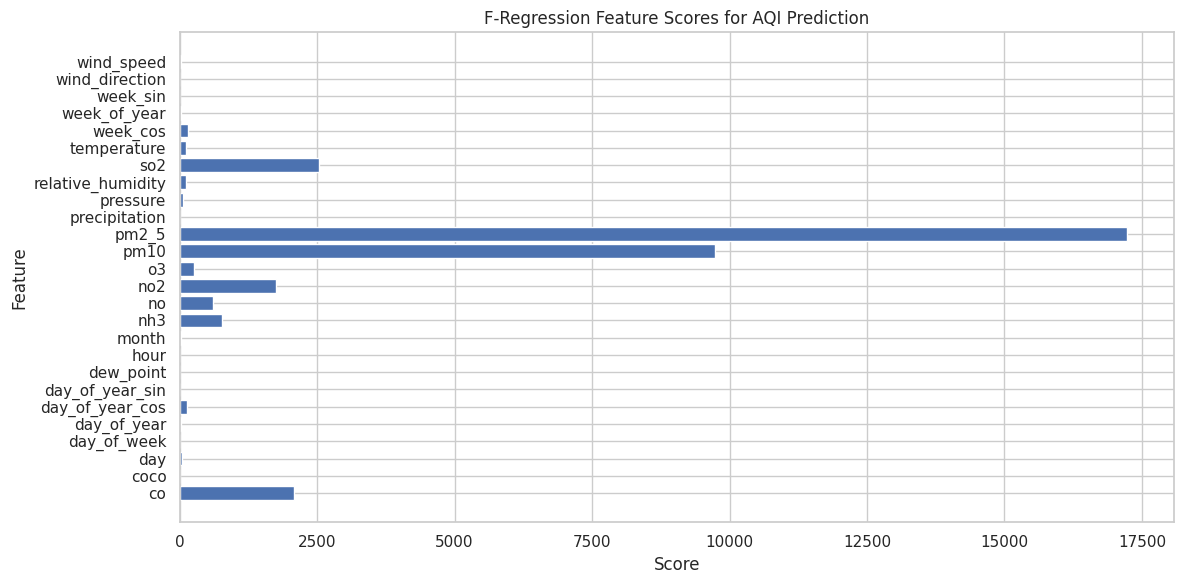

In [76]:
import matplotlib.pyplot as plt

# Plot feature scores
scores = selector.scores_
plt.figure(figsize=(12, 6))
plt.barh(X.columns, scores)
plt.title("F-Regression Feature Scores for AQI Prediction")
plt.xlabel("Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
#relevance of each feature in predicting AQI, with a higher score indicating a more important feature. It's a critical step in feature selection,

In [77]:
# Reconfirm shape and contents
print(" Final dataset preview:")
df.head()

 Final dataset preview:


,co,coco,day,day_of_week,day_of_year,day_of_year_cos,day_of_year_sin,dew_point,hour,month,...,pressure,relative_humidity,so2,temperature,week_cos,week_of_year,week_sin,wind_direction,wind_speed,numerical_aqi
0,0.413606,0.166667,0.1,0.166667,0.0,1.0,0.936907,0.491841,0.000000,0.0,...,0.758427,0.94,0.122310,0.051546,1.0,0.0,0.965534,0.000000,0.000000,178.0
1,0.383275,0.166667,0.1,0.166667,0.0,1.0,0.936907,0.466200,0.043478,0.0,...,0.758427,1.00,0.118551,0.000000,1.0,0.0,0.965534,0.608333,0.078313,175.0
2,0.393386,0.166667,0.1,0.166667,0.0,1.0,0.936907,0.466200,0.086957,0.0,...,0.786517,1.00,0.138709,0.000000,1.0,0.0,0.965534,0.625000,0.078313,176.0
3,0.474267,0.166667,0.1,0.166667,0.0,1.0,0.936907,0.512821,0.130435,0.0,...,0.848315,1.00,0.163307,0.051546,1.0,0.0,0.965534,0.500000,0.043373,180.0
4,0.575370,0.166667,0.1,0.166667,0.0,1.0,0.936907,0.463869,0.173913,0.0,...,0.814607,0.76,0.185514,0.103093,1.0,0.0,0.965534,0.563889,0.060241,186.0


In [78]:
print(f"\nRows: {df.shape[0]}, Columns: {df.shape[1]}")


Rows: 4001, Columns: 27


In [79]:
# Save to clean final path
df.to_csv("/content/final_ready.csv", index=False)
print("Final cleaned dataset saved to /content/final_ready.csv")

Final cleaned dataset saved to /content/final_ready.csv


In [80]:
df.head()

,co,coco,day,day_of_week,day_of_year,day_of_year_cos,day_of_year_sin,dew_point,hour,month,...,pressure,relative_humidity,so2,temperature,week_cos,week_of_year,week_sin,wind_direction,wind_speed,numerical_aqi
0,0.413606,0.166667,0.1,0.166667,0.0,1.0,0.936907,0.491841,0.000000,0.0,...,0.758427,0.94,0.122310,0.051546,1.0,0.0,0.965534,0.000000,0.000000,178.0
1,0.383275,0.166667,0.1,0.166667,0.0,1.0,0.936907,0.466200,0.043478,0.0,...,0.758427,1.00,0.118551,0.000000,1.0,0.0,0.965534,0.608333,0.078313,175.0
2,0.393386,0.166667,0.1,0.166667,0.0,1.0,0.936907,0.466200,0.086957,0.0,...,0.786517,1.00,0.138709,0.000000,1.0,0.0,0.965534,0.625000,0.078313,176.0
3,0.474267,0.166667,0.1,0.166667,0.0,1.0,0.936907,0.512821,0.130435,0.0,...,0.848315,1.00,0.163307,0.051546,1.0,0.0,0.965534,0.500000,0.043373,180.0
4,0.575370,0.166667,0.1,0.166667,0.0,1.0,0.936907,0.463869,0.173913,0.0,...,0.814607,0.76,0.185514,0.103093,1.0,0.0,0.965534,0.563889,0.060241,186.0


In [81]:
#Train Baseline Linear Regression Model
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
import joblib

# Load training data
X_train = pd.read_csv("/content/X_train.csv")
y_train = pd.read_csv("/content/y_train.csv")

# Fill NaNs with mean values
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

# Train the baseline model
model = LinearRegression()
model.fit(X_train_imputed, y_train)

# Save model and imputer for future use
joblib.dump(model, "/content/linear_regression_model.pkl")
joblib.dump(imputer, "/content/imputer.pkl")  # Optional, for use during prediction

print(" Linear Regression model trained and saved as /content/linear_regression_model.pkl")


 Linear Regression model trained and saved as /content/linear_regression_model.pkl


✅ 2. Evaluate Model Performance on Test Set


/tmp/ipython-input-3459147221.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  aqi_df = aqi_df.set_index('timestamp').asfreq('H')
/tmp/ipython-input-3459147221.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  aqi_df.fillna(method='ffill', inplace=True)
/tmp/ipython-input-3459147221.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  aqi_df.fillna(method='bfill', inplace=True)


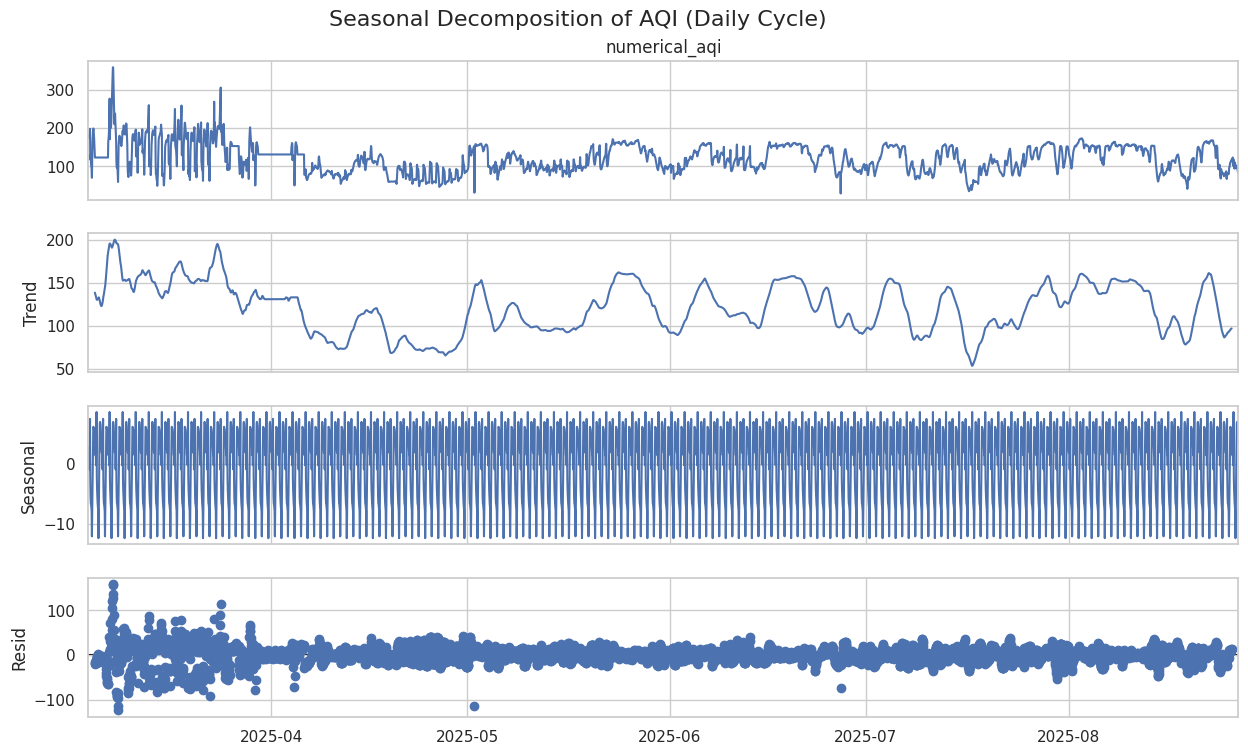

In [82]:
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd # Import pandas
import matplotlib.pyplot as plt # Import matplotlib

# Load AQI data again to ensure 'timestamp' is a column
aqi_df = pd.read_csv("/content/merged_with_numerical_aqi.csv")
aqi_df['timestamp'] = pd.to_datetime(aqi_df['timestamp'])


# Ensure timestamp is index
aqi_df = aqi_df.set_index('timestamp').asfreq('H')

# Fill missing values using forward fill
aqi_df.fillna(method='ffill', inplace=True)

# Then backfill any leftover at top of dataset (optional)
aqi_df.fillna(method='bfill', inplace=True)

# Ensure the number of observations is divisible by the period
period = 48
remainder = len(aqi_df) % period
if remainder != 0:
    aqi_df = aqi_df[:-remainder]

# Decompose AQI time series
decomposition = seasonal_decompose(aqi_df['numerical_aqi'], model='additive', period=period)  # daily cycle
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Seasonal Decomposition of AQI (Daily Cycle)", fontsize=16)
plt.show()

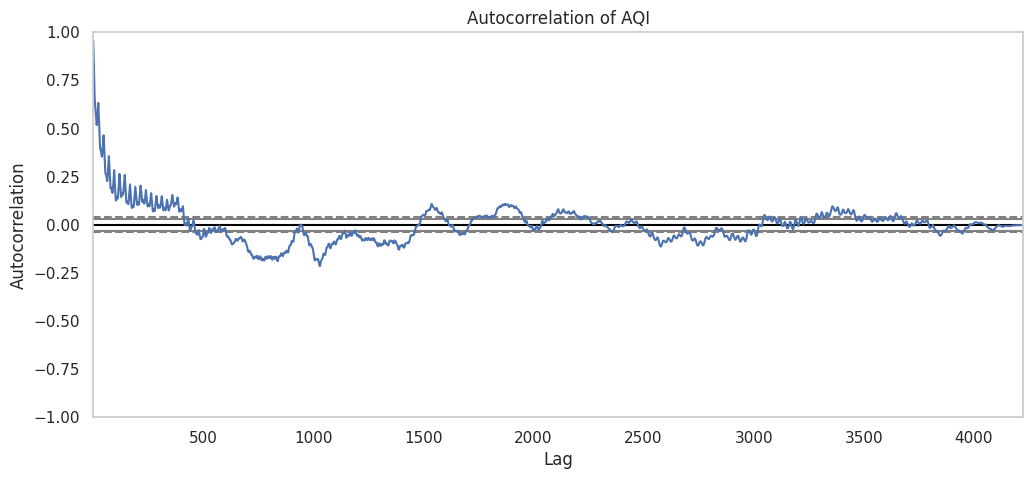

In [83]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(12,5))
autocorrelation_plot(aqi_df['numerical_aqi'].dropna())
plt.title("Autocorrelation of AQI")
plt.show()
#correlation of AQI values with their past values over time. It helps determine the appropriate lag features for the models, as the high initial correlation shows that recent history is very predictive of future AQI.

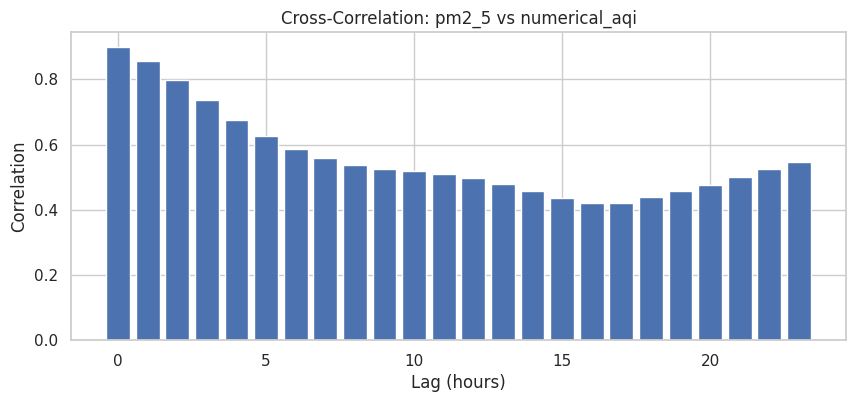

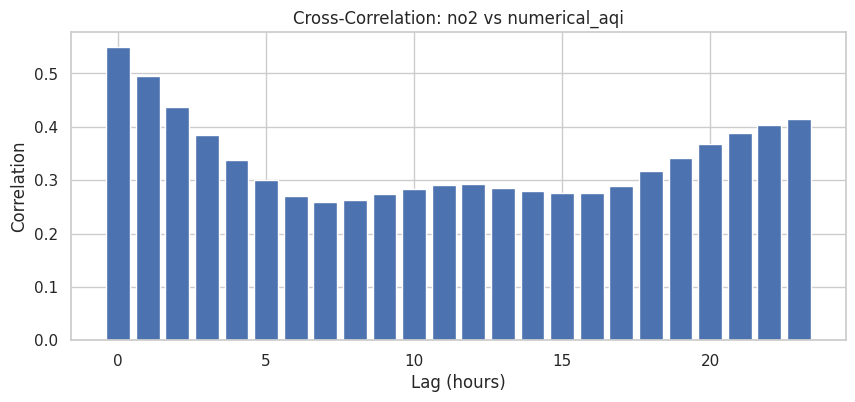

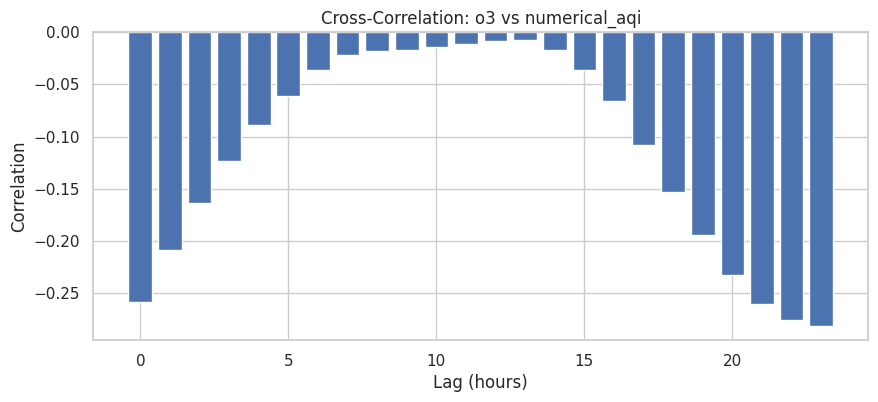

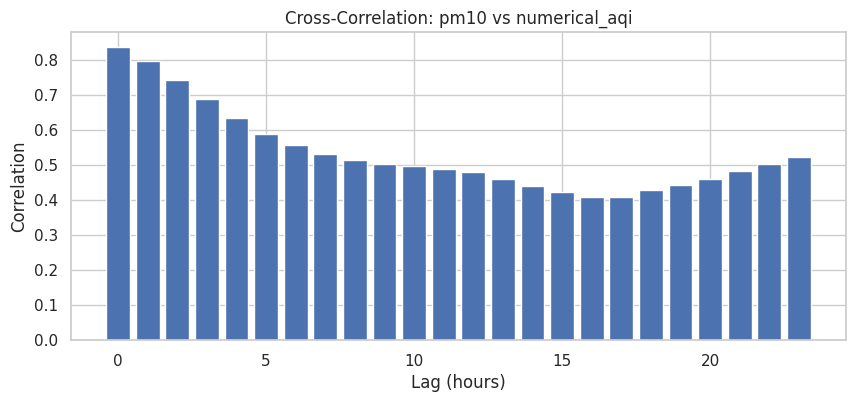

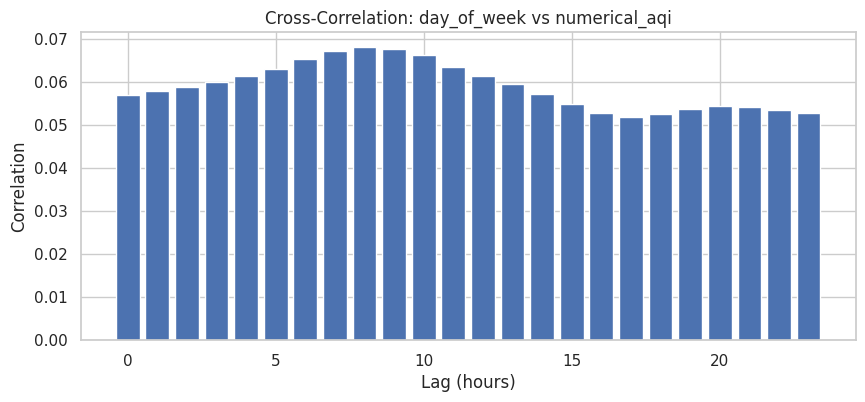

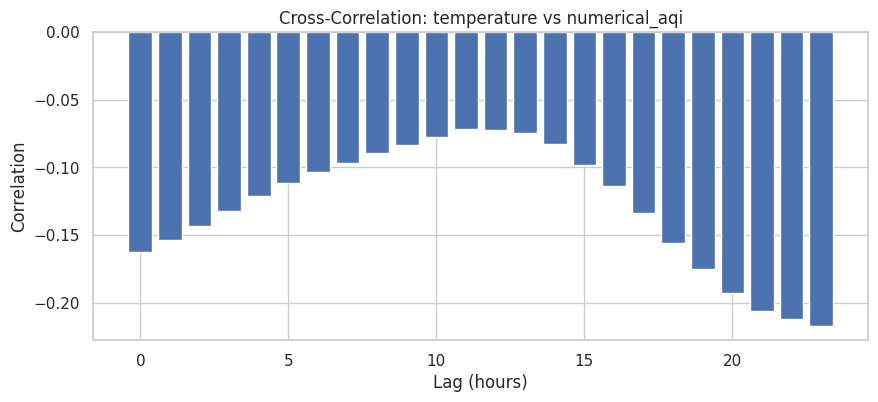

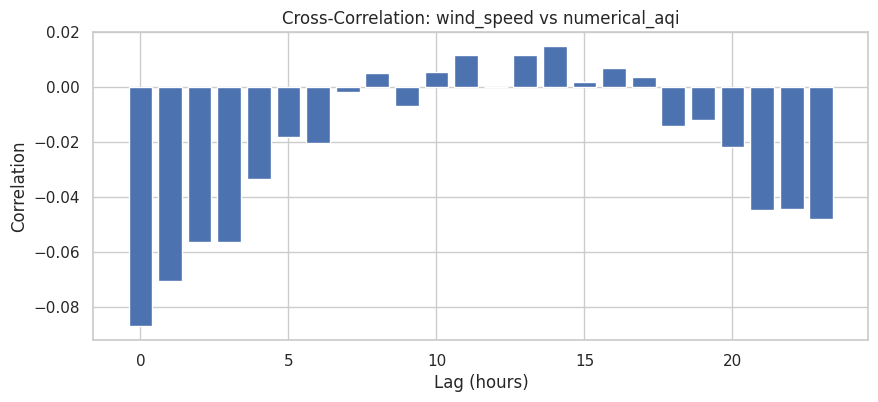

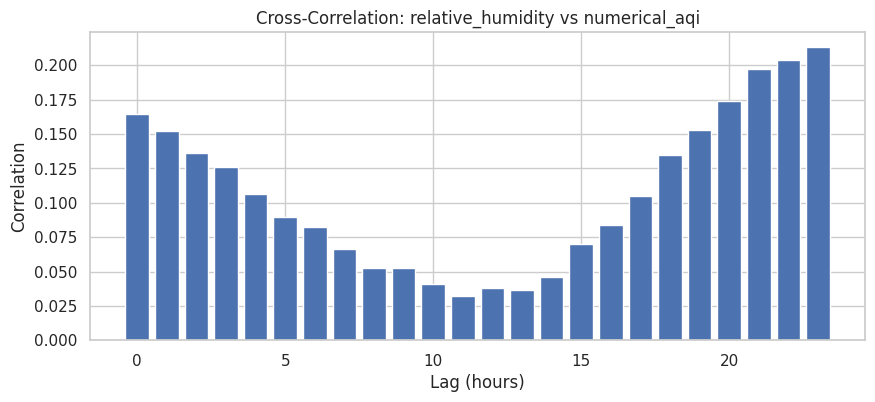

In [84]:
def cross_correlation_plot(df, col, target='numerical_aqi', lags=24):
    from statsmodels.tsa.stattools import ccf
    x = df[col].fillna(0)
    y = df[target].fillna(0)
    corr = ccf(x, y)[:lags]

    plt.figure(figsize=(10,4))
    plt.bar(range(lags), corr)
    plt.title(f"Cross-Correlation: {col} vs {target}")
    plt.xlabel("Lag (hours)")
    plt.ylabel("Correlation")
    plt.show()

# Example: PM2.5 vs AQI
cross_correlation_plot(aqi_df, 'pm2_5')
cross_correlation_plot(aqi_df, 'no2')
cross_correlation_plot(aqi_df, 'o3')
cross_correlation_plot(aqi_df, 'pm10')
cross_correlation_plot(aqi_df, 'day_of_week')
cross_correlation_plot(aqi_df, 'temperature')
cross_correlation_plot(aqi_df, 'wind_speed')
cross_correlation_plot(aqi_df, 'relative_humidity')


#correlation between past feature values and the current AQI, showing a strong relationship. It is crucial for feature engineering, as it helps determine the optimal time lags for each feature


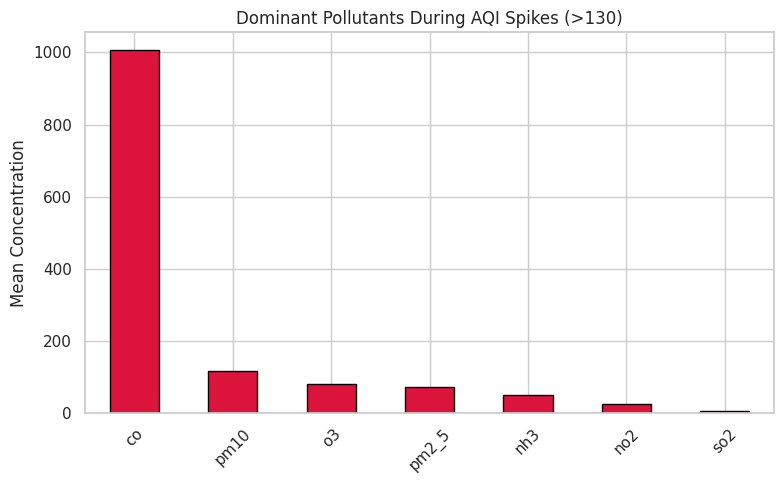

In [85]:
# When AQI > 130 (very unhealthy)
spike_df = aqi_df[aqi_df['numerical_aqi'] > 130]

pollutants = ['pm2_5','pm10','no2','so2','o3','co','nh3']
mean_spike = spike_df[pollutants].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
mean_spike.plot(kind='bar', color='crimson', edgecolor='black')
plt.title("Dominant Pollutants During AQI Spikes (>130)")
plt.ylabel("Mean Concentration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# identifies which pollutants are most responsible for high AQI events. By showing that CO, PM10, and O3 are the main drivers of pollution spikes, it helps the system focus on these key features

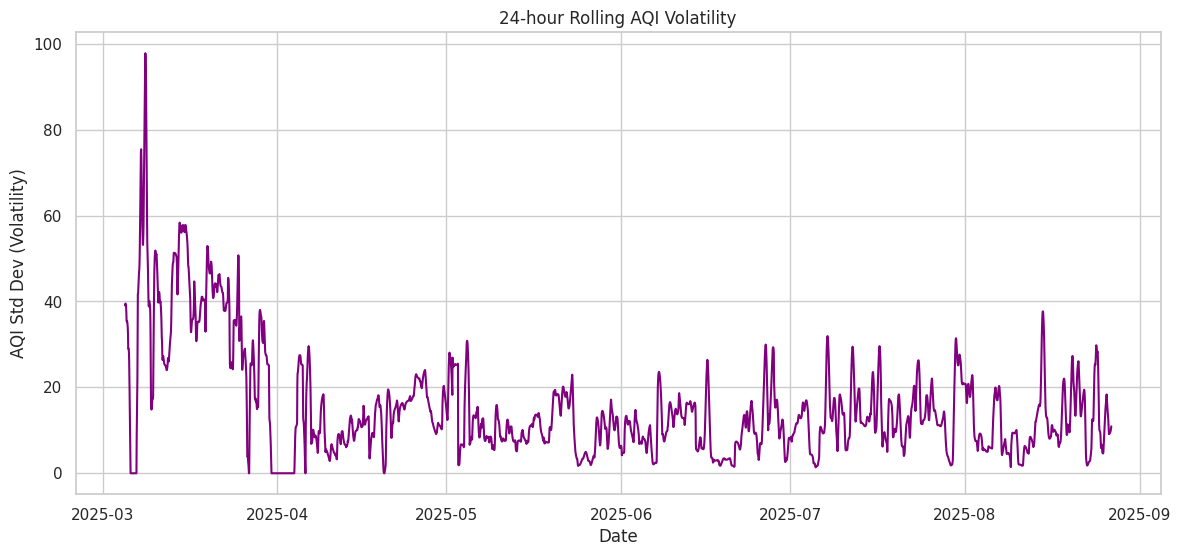

In [86]:
aqi_df['aqi_volatility'] = aqi_df['numerical_aqi'].rolling(24).std()

plt.figure(figsize=(14,6))
plt.plot(aqi_df.index, aqi_df['aqi_volatility'], color='purple')
plt.title("24-hour Rolling AQI Volatility")
plt.xlabel("Date")
plt.ylabel("AQI Std Dev (Volatility)")
plt.grid(True)
plt.show()
#visualizes the short-term fluctuations and stability of AQI, highlighting periods of high and low volatility

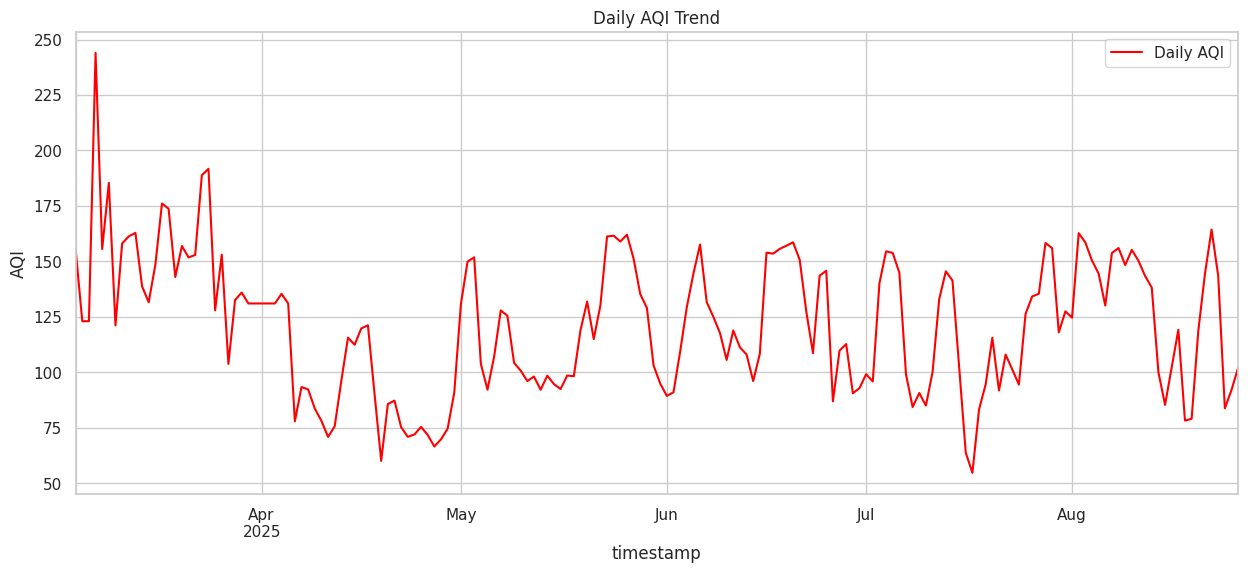

In [87]:
# Resample daily
daily_aqi = aqi_df["numerical_aqi"].resample("D").mean()

plt.figure(figsize=(15,6))
daily_aqi.plot(color="red", label="Daily AQI")
plt.title("Daily AQI Trend")
plt.ylabel("AQI")
plt.legend()
plt.show()

#It confirms that the data has a time-series nature, making it a suitable candidate for time-series forecasting models and helping to identify the overall patterns that the system needs to predict.

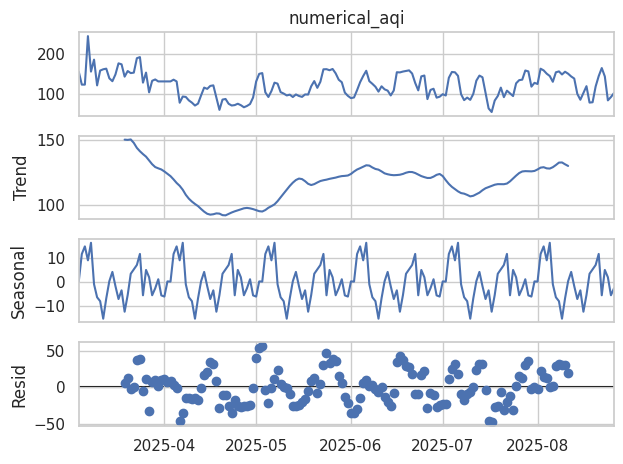

In [88]:
# Seasonal decomposition (works best on daily data)
result = seasonal_decompose(daily_aqi.dropna(), model="additive", period=30)

result.plot()
plt.show()
#plot decomposes the AQI time-series into its core components: trend, seasonality, and residuals. This helps the system by explicitly isolating the long-term trends and periodic cycles in the data, which informs the design of the forecasting models (such as TCN) to capture these patterns accurately.

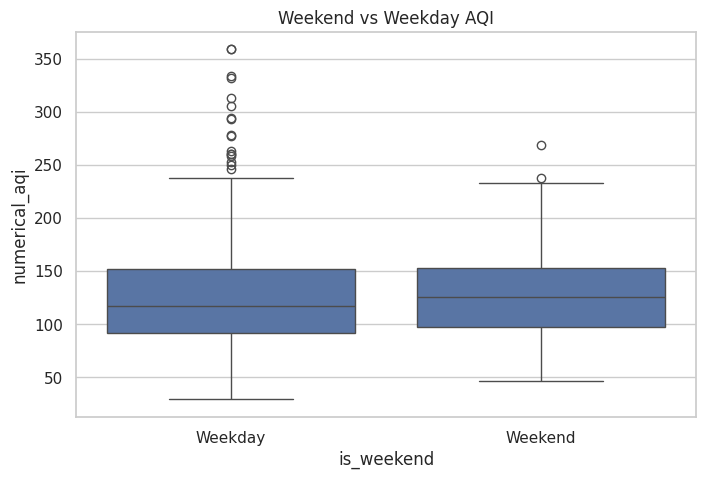

In [89]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_weekend", y="numerical_aqi", data=aqi_df.reset_index())
plt.title("Weekend vs Weekday AQI")
plt.xticks([0,1], ["Weekday", "Weekend"])
plt.show()
#compare the distribution of AQI on weekends versus weekdays, revealing distinct patterns. This insight informs the creation of a crucial 'is_weekend' feature
